In [ ]:
%pip install -q pandas numpy matplotlib scipy pyyaml ipywidgets

Note: you may need to restart the kernel to use updated packages.


# Extended Analysis: AlphaReQ

**Research question:** *Do AlphaReQ (α) trajectory features during pre-training predict downstream multilingual performance? Specifically: do post-minimum self-regularization levels, the initial rate of α increase, and trajectory-averaged α values during the regularization-decreasing phase correlate with accuracy and grokking behaviour on m-MMLU, XCOPA, Belebele, and M-ARC?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages) · Belebele (5-shot, 10 languages) · M-ARC (5-shot, 9 languages) — configured in `code/downstream_evaluation/configs/benchmarks.yaml`  
**Geometry source:** `fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`

### What this notebook does

1. **Layer selection** — measures cross-language AlphaReQ stratification at each layer to identify the most informative layer. Layer 15 is used for FuxiTranyu-8B and layer 21 for Apertus-8B-2509 — the same layers as the RankMe analysis, enabling direct comparison between the two metrics.

2. **AlphaReQ trajectory analysis** — for each language, identifies the α trough (global minimum, point of maximum self-regularization) and computes nine post-minimum geometry predictors: AlphaReQ at the minimum, initial increase rate, and trajectory-averaged means over the regularization-decreasing phase. All predictors are computed from the post-minimum phase only, since the regularization-increasing phase is not observable for Apertus (the trough falls at or before the first checkpoint). The first observable checkpoint for Apertus is 210B tokens.

3. **Grokking detection** — finds the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints. Separately per task and language.

4. **Overlay plots** — dual-axis plots overlaying the AlphaReQ trajectory and accuracy curve per language, with grokking onset marked. Split into regularization-increasing (blue) and regularization-decreasing (purple) phases. One plot per task (m-MMLU, XCOPA, Belebele, M-ARC).

5. **Predictor correlation analysis** — tests nine post-minimum AlphaReQ predictors against two outcomes (grokking onset, peak accuracy) using Spearman and Pearson correlations. Grokking onset uses only AlphaReQ at the first checkpoint (at or before grokking onset); peak accuracy uses all nine post-minimum predictors. Computed separately per task, never pooled across tasks.

6. **Per-checkpoint cross-language correlation** — at every training checkpoint, computes the Spearman rank correlation between AlphaReQ and accuracy *across languages*, yielding a trajectory that shows when and how strongly the self-regularization geometry tracks the live language performance hierarchy.

In [2]:
import warnings

import pandas as pd

from utils import (
    load_config, init_models,
    load_rankme_data, load_eval_data, load_model_data,
    compute_alpha_phases, compute_and_show_alpha_phases,
    compute_grokking, compute_and_show_grokking,
    compute_alpha_correlations_table, compute_and_show_alpha_correlations,
    compute_checkpoint_correlations, compute_and_show_checkpoint_correlations,
    show_stratification,
    plot_alpha_phases, show_alpha_phases,
    show_alpha_overlay_widget,
    show_alpha_correlation_heatmap,
    show_predictor_scatter,
    plot_checkpoint_correlations, show_checkpoint_correlations,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

The notebook analyses **both models simultaneously**. `init_models()` loads config, colors, and benchmark metadata from `configs/benchmarks.yaml` for each model.

In [3]:
MODELS, data = init_models()

[fuxi] FuxiTranyu-8B  |  Layer: layer_15  |  Aggregation: last
[apertus] Apertus-8B-2509  |  Layer: layer_21  |  Aggregation: last


## Layer Selection

AlphaReQ is computed at every layer and checkpoint, but the phase and correlation analyses require choosing one representative layer per model. To select the most informative layer, we measure the **cross-language AlphaReQ stratification signal** at each layer: for each language we average AlphaReQ across all training checkpoints, then compute the standard deviation of those per-language averages across languages.

**A high standard deviation means the layer separates languages strongly** in terms of self-regularization geometry — this is the layer with the most signal for predicting per-language downstream outcomes.

The figure below shows this stratification signal across all layers for both models. The selected layer (peak std) is marked with a coloured dashed line.

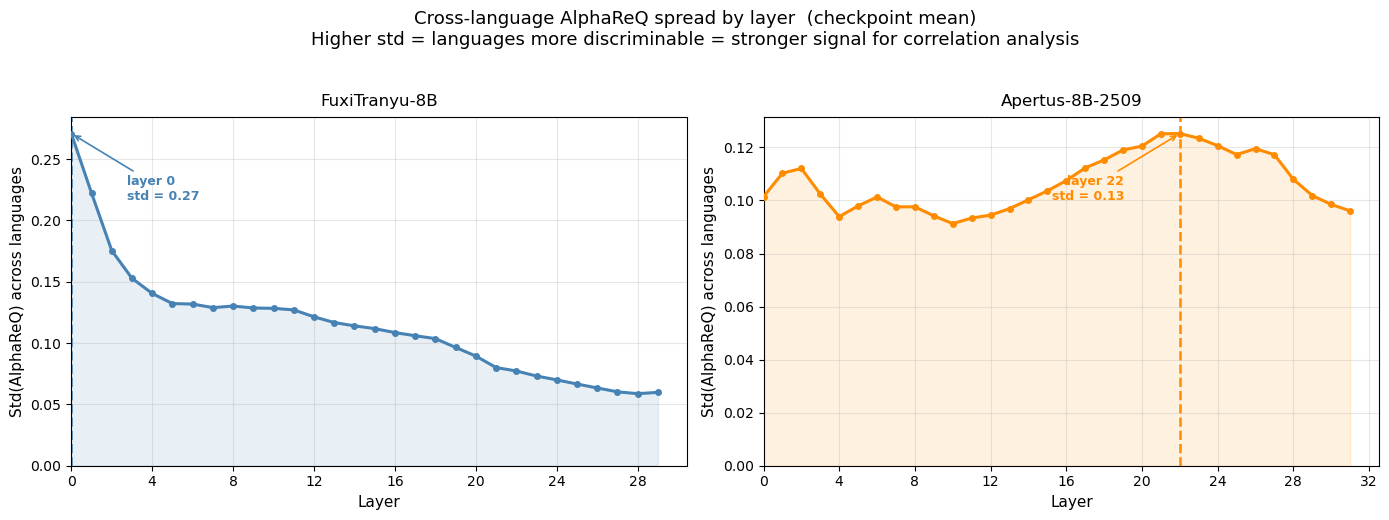

Saved: plots/alpha_req_layer_stratification.png


In [4]:
show_stratification(MODELS, data, metric="alpha_req")

### Selected layers

- **FuxiTranyu-8B → layer 15** (same as RankMe analysis): unlike RankMe, which peaks at layer 15 with std = 160.9, the AlphaReQ stratification signal decreases *monotonically* across layers (layer 0: std = 0.271, layer 29: std = 0.059). There is no natural peak, meaning the layer selection criterion that works for RankMe breaks down for AlphaReQ in this model. Layer 0 (the embedding layer, before any attention or FFN processing) is the mathematical maximum but is not meaningful for analysis. We therefore adopt the same layer as the RankMe analysis to maintain consistency and allow direct comparison between the two metrics.
- **Apertus-8B-2509 → layer 21** (std = 0.1252): the AlphaReQ stratification independently confirms the same layer as RankMe. Layers 21 and 22 are tied (both 0.1252); layer 21 is selected for consistency.

These are the layers used throughout this notebook for all AlphaReQ phase and correlation analyses.

## Data

Two sources are loaded:

- **`fuxi_fine_wiki.csv` / `apertus_fine_wiki.csv`** — geometry metrics for all checkpoints, all languages, and all layers. Used for layer selection, trajectory plots, and per-checkpoint correlation.

- **`fuxi_fine_wiki_mmlu_xcopa_belebele_marc_layer15_merged.csv` / `apertus_fine_wiki_mmlu_xcopa_belebele_marc_layer21_merged.csv`** — downstream accuracy for all four benchmarks merged with geometry at the selected layer. Used for grokking detection, correlation analysis, and overlay plots.

In [5]:
load_model_data(MODELS, data)

Loaded geometry data: 47,880 rows — 57 checkpoints, 14 languages
Working slice : layer_15, agg=last → 798 rows
Loaded eval: 1824 records — 4 task(s), 57 checkpoint(s)

Loaded geometry data: 39,424 rows — 44 checkpoints, 14 languages
Working slice : layer_21, agg=last → 616 rows
Loaded eval: 1408 records — 4 task(s), 44 checkpoint(s)



## AlphaReQ Trajectories

The table below summarises key AlphaReQ (α) phase metrics and post-minimum geometry predictors per language, derived from the AlphaReq trajectory at the working layer:

- **AlphaReQ first ckpt** — self-regularization level at the first checkpoint (= minimum for Apertus).
- **trough (B)** — token count where α reaches its global minimum (point of maximum self-regularization). Defines the boundary between the regularization-increasing and regularization-decreasing phases, and the start of the post-minimum token range used by all predictors below.

**Post-minimum predictors** (used in the correlation analysis; all computed from the regularization-decreasing phase):
- **AlphaReQ at minimum** — self-regularization level at the trough.
- **AlphaReQ last ckpt** — self-regularization level at the end of training.
- **initial increase rate (1/B)** — rate of α rise from the trough to the 25% mark of the post-minimum token range.
- **mean first 25% post-min** — mean AlphaReQ over the first quarter of the post-minimum token range.
- **mean first 50% post-min** — mean AlphaReQ over the first half of the post-minimum token range.
- **mean last 50% post-min** — mean AlphaReQ over the last half of the post-minimum token range.
- **mean last 25% post-min** — mean AlphaReQ over the last quarter of the post-minimum token range.
- **mean full post-min** — mean AlphaReQ over all post-minimum checkpoints.

In [6]:
compute_and_show_alpha_phases(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
  language  trough (B)  AlphaReQ first ckpt  AlphaReQ at minimum  AlphaReQ last ckpt  initial increase rate (1/B)  mean first 25% post-min  mean first 50% post-min  mean last 50% post-min  mean last 25% post-min  mean full post-min
    Arabic       241.0             0.861684             0.796887            0.826469                     0.000222                 0.811996                 0.815986                0.824540                0.826089            0.820141
   Chinese       241.0             0.796379             0.727908            0.749674                     0.000140                 0.736368                 0.739640                0.747354                0.749128            0.743387
   English       241.0             0.706776             0.623338            0.636397                     0.000060                 0.626694                 0.628707                0.634699                0.635754            0.631618
   Finnish   

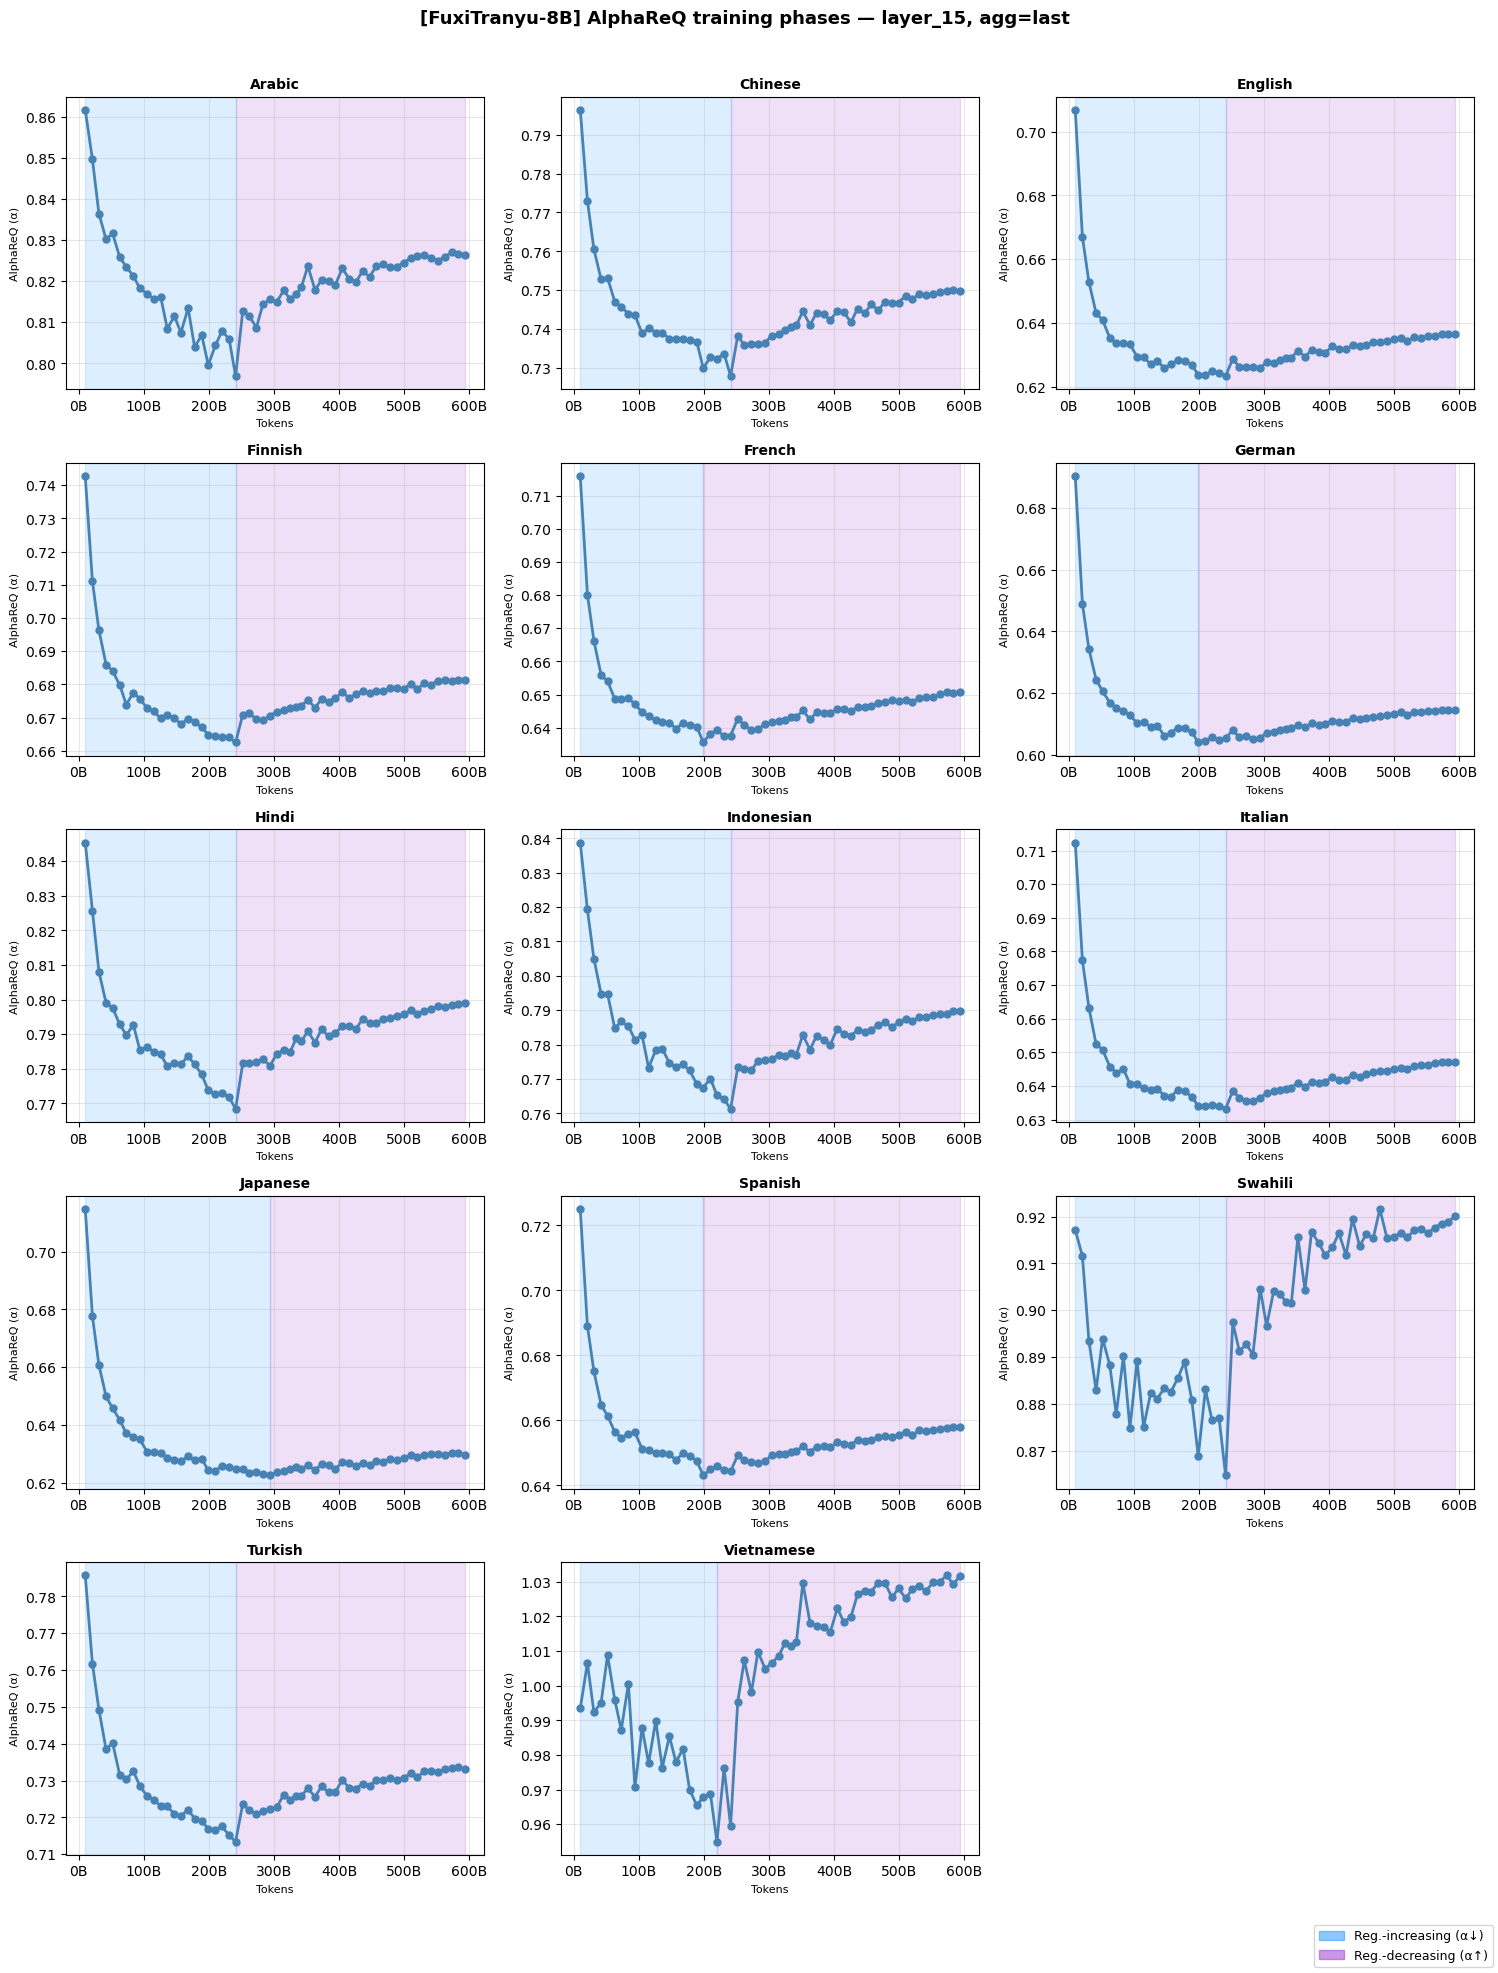

Saved: plots/alpha_phases_fuxi.png


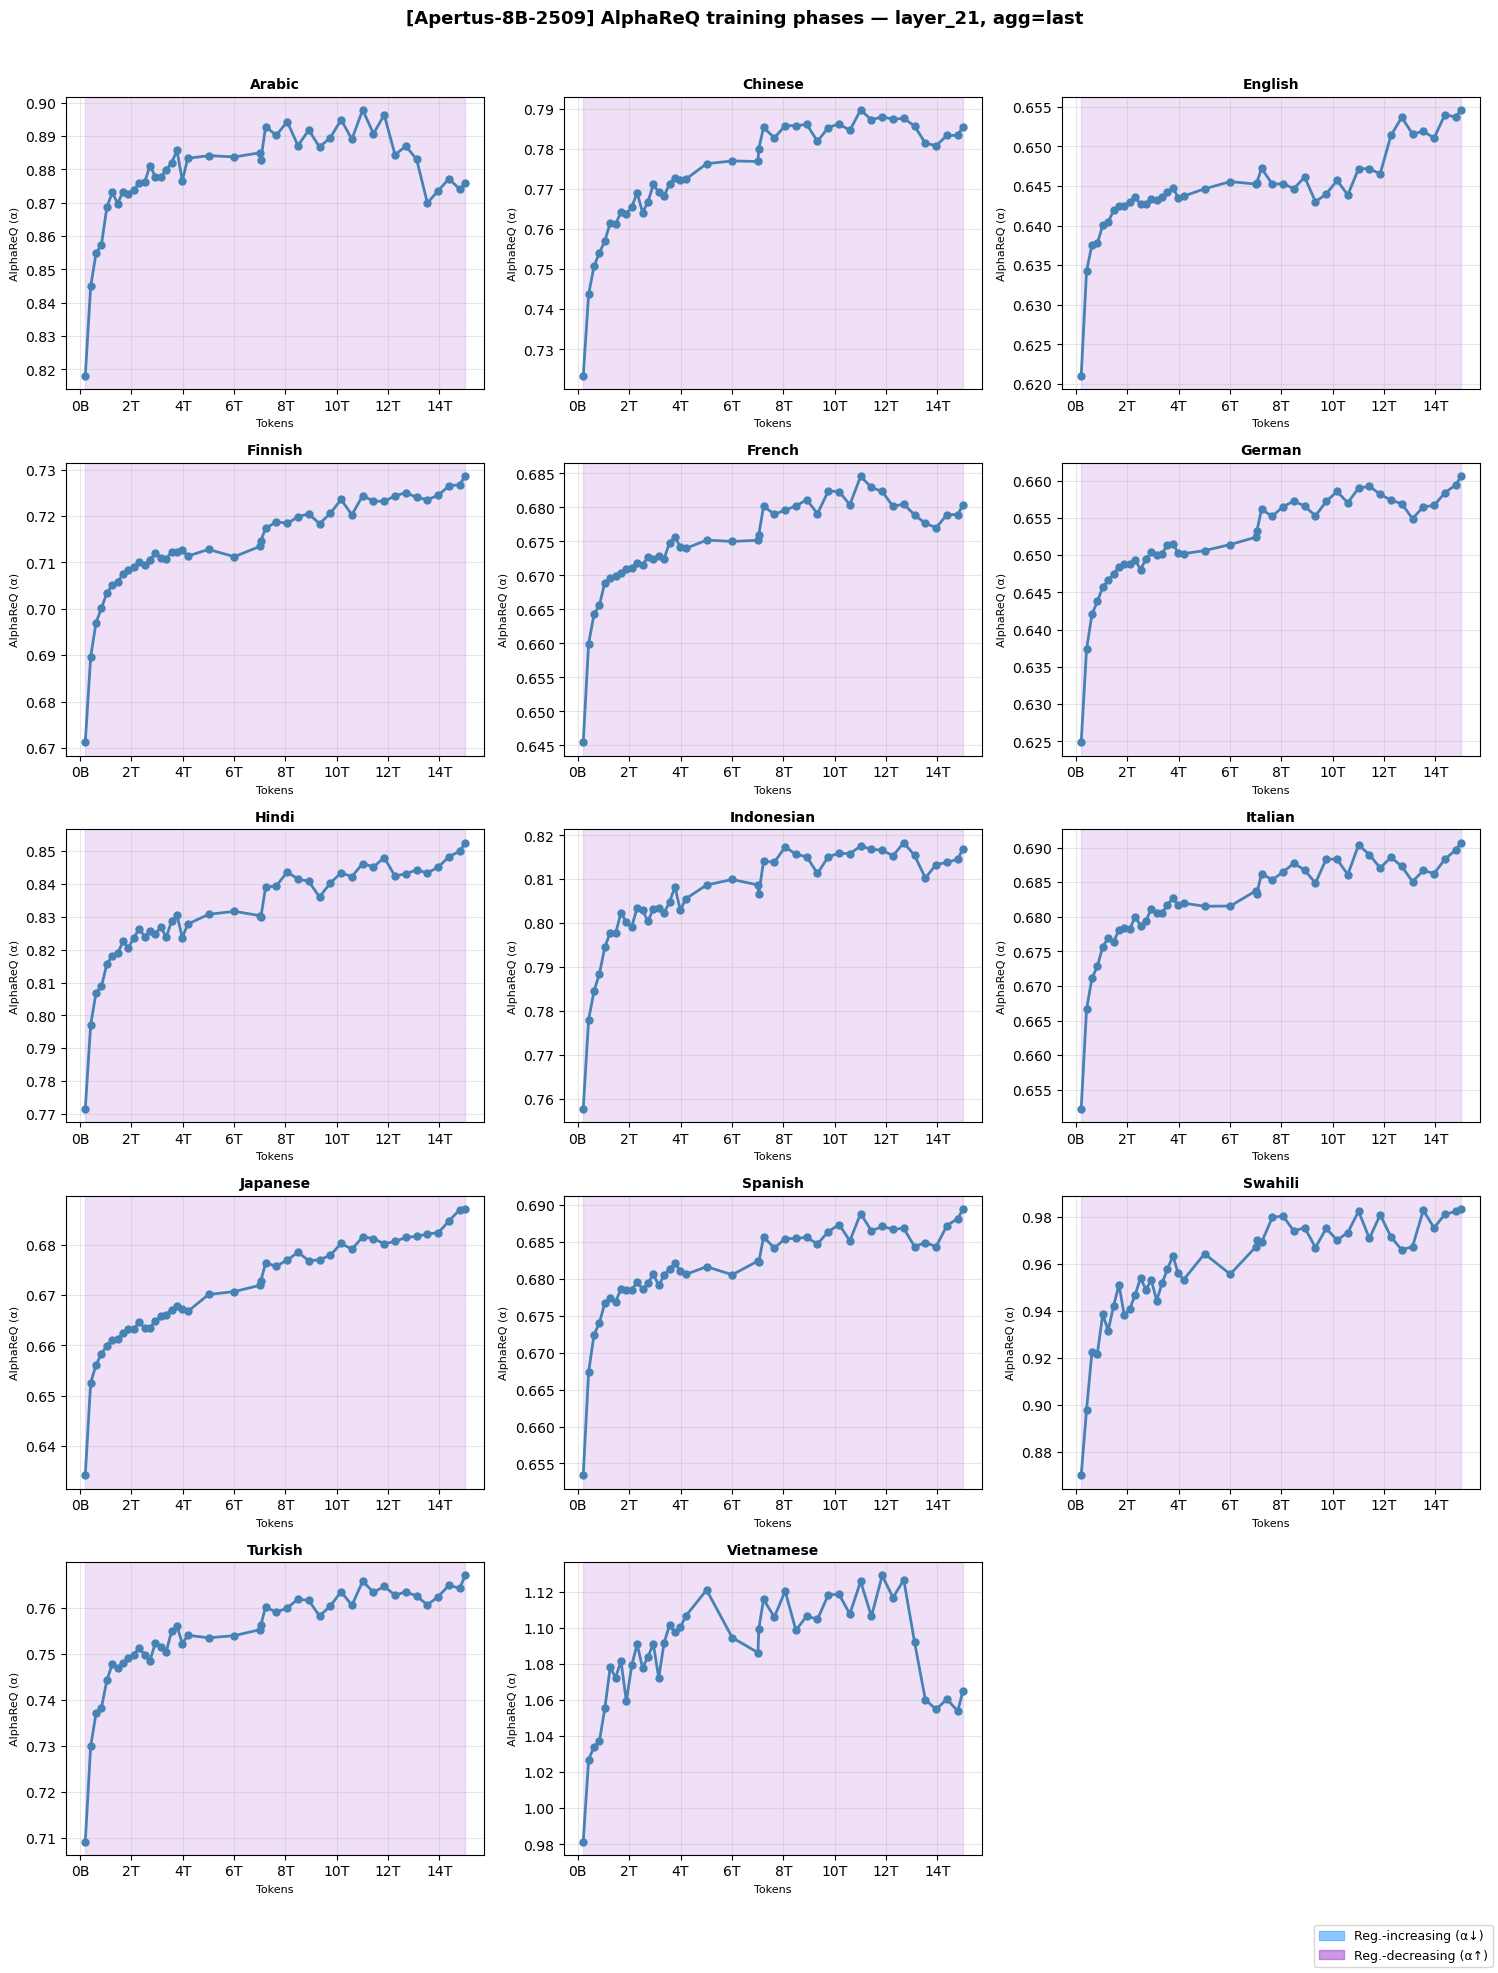

Saved: plots/alpha_phases_apertus.png


In [7]:
show_alpha_phases(MODELS, data)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task. Grokking onset and peak accuracy serve as the outcome variables for the AlphaReQ correlation analysis.

- **grokking_tokens (B)** — token count at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, Belebele, and M-ARC; 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [8]:
compute_and_show_grokking(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
  m_mmlu    English                 NaN     115.0       0.272590           0.25
  m_mmlu    Chinese                 NaN     334.0       0.272921           0.25
  m_mmlu     German                 NaN     199.0       0.274928           0.25
  m_mmlu    Spanish                 NaN     241.0       0.276211           0.25
  m_mmlu    Italian                 NaN     415.0       0.275818           0.25
  m_mmlu     Arabic                 NaN     531.0       0.273824           0.25
  m_mmlu      Hindi                 NaN     210.0       0.269438           0.25
  m_mmlu Indonesian                 NaN     115.0       0.273033           0.25
   xcopa    Chinese               325.0     426.0       0.664000           0.50
   xcopa    Italian               241.0     520.0       0.718000           0.50
   xcopa Vietnamese               126.0     436.0       0.736

## Overlay Plots

One plot per task , with one panel per language. Each panel shows two y-axes:

- **Left axis (blue)** — AlphaReQ (α) trajectory across all checkpoints.
- **Right axis (red, dashed)** — downstream accuracy across all checkpoints. The axis always spans 0 to 1.

Shaded regions mark the two α phases (blue = regularization-increasing, purple = regularization-decreasing). The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, Belebele, and M-ARC; 0.50 for XCOPA). A purple vertical dashed line marks the grokking onset for that language — absent when grokking was not detected.

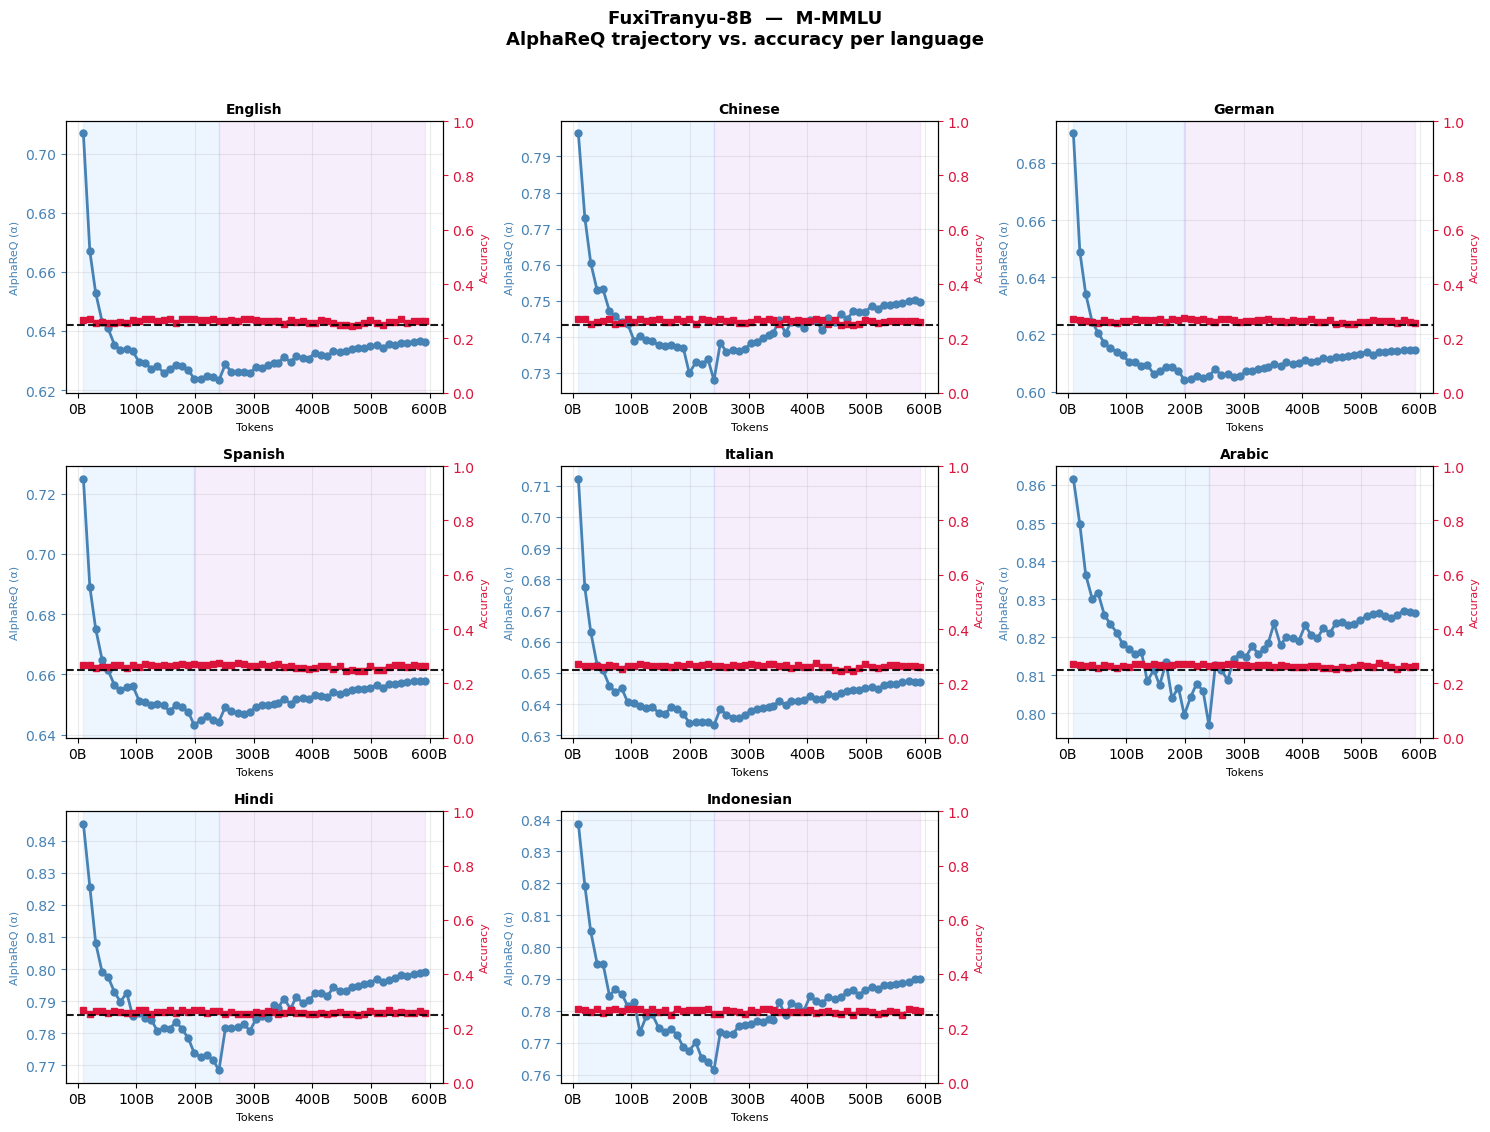

Saved: plots/alpha_overlay_m_mmlu_fuxi.png


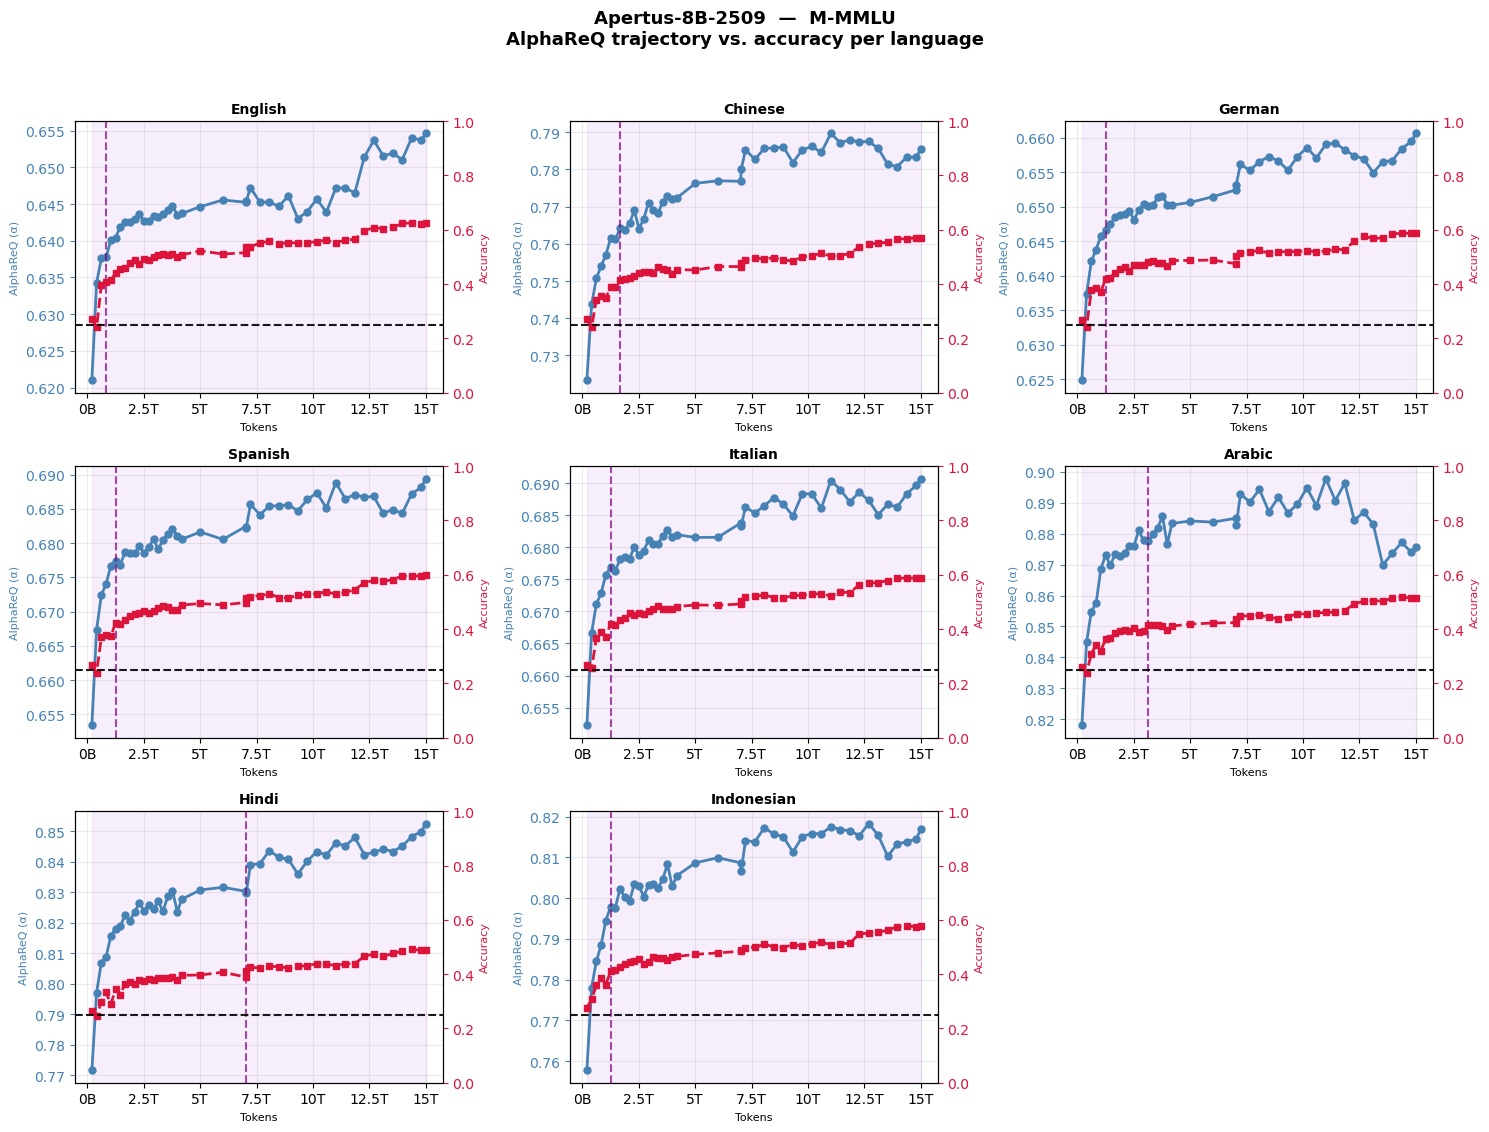

Saved: plots/alpha_overlay_m_mmlu_apertus.png


In [9]:
show_alpha_overlay_widget(MODELS, data)

## AlphaReQ Geometry–Performance Correlation: Do post-minimum trajectory features predict grokking onset and peak accuracy?

Tests whether AlphaReQ geometry predicts downstream performance. The predictor set depends on the outcome:

**Grokking onset** uses only **AlphaReQ at first ckpt** — the single checkpoint guaranteed to be at or before grokking onset in every (model, task, language) combination. 

**Peak accuracy** uses all **nine predictors** below (retrospective — no leakage risk):
- **AlphaReQ at first ckpt** — self-regularization level at the start of training. For Apertus the first checkpoint (210B) coincides with the α trough, so it sits on the boundary of the post-minimum phase. For Fuxi the first checkpoint (10B) falls in the **regularization-increasing phase** (before the trough), since Fuxi's troughs range from 199B to 294B depending on language.

The remaining eight predictors are all computed strictly from the **regularization-decreasing phase** (post-minimum):
- **AlphaReQ at minimum** — self-regularization level at the trough (start of regularization-decreasing phase).
- **AlphaReQ at last ckpt** — self-regularization level at the end of training.
- **Initial AlphaReQ increase rate (1/B)** — (α[first 25% of post-min range] − α[minimum]) / Δtokens; how steeply α rises in the early part of the regularization-decreasing phase.
- **Mean AlphaReQ — first 25% post-minimum** — average over checkpoints in the first quarter of the post-minimum token range.
- **Mean AlphaReQ — first 50% post-minimum** — average over checkpoints in the first half of the post-minimum token range.
- **Mean AlphaReQ — last 50% post-minimum** — average over checkpoints in the last half of the post-minimum token range.
- **Mean AlphaReQ — last 25% post-minimum** — average over checkpoints in the last quarter of the post-minimum token range.
- **Mean AlphaReQ — full post-minimum** — average over all post-minimum checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported, computed separately per task and never pooled.

In [10]:
compute_and_show_alpha_correlations(MODELS, data)


── FuxiTranyu-8B ────────────────────────────────────────
    task                          predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
  m_mmlu                 AlphaReQ at first ckpt Grokking onset (B)            0         NaN         NaN        NaN        NaN
  m_mmlu                 AlphaReQ at first ckpt      Peak accuracy            8     -0.3095      0.4556    -0.5944     0.1202
  m_mmlu                    AlphaReQ at minimum      Peak accuracy            8     -0.3095      0.4556    -0.5722     0.1383
  m_mmlu                  AlphaReQ at last ckpt      Peak accuracy            8     -0.3095      0.4556    -0.5799     0.1319
  m_mmlu   Initial AlphaReQ increase rate (1/B)      Peak accuracy            8     -0.4762      0.2329    -0.6171     0.1032
  m_mmlu Mean AlphaReQ — first 25% post-minimum      Peak accuracy            8     -0.3095      0.4556    -0.5743     0.1365
  m_mmlu Mean AlphaReQ — first 50% post-minimum      Peak a

### Correlation Heatmap

The table above has rows for each (task × outcome × predictor) combination. The heatmap below condenses all of them into a single 9×8 figure per model (rows = all 9 post-minimum predictors, columns = tasks × outcomes). Colour encodes Spearman ρ; * marks p < 0.05. Gray cells indicate undefined correlations or predictors not used for that outcome — the 8 non-first-checkpoint predictor rows are gray in all grokking onset columns.

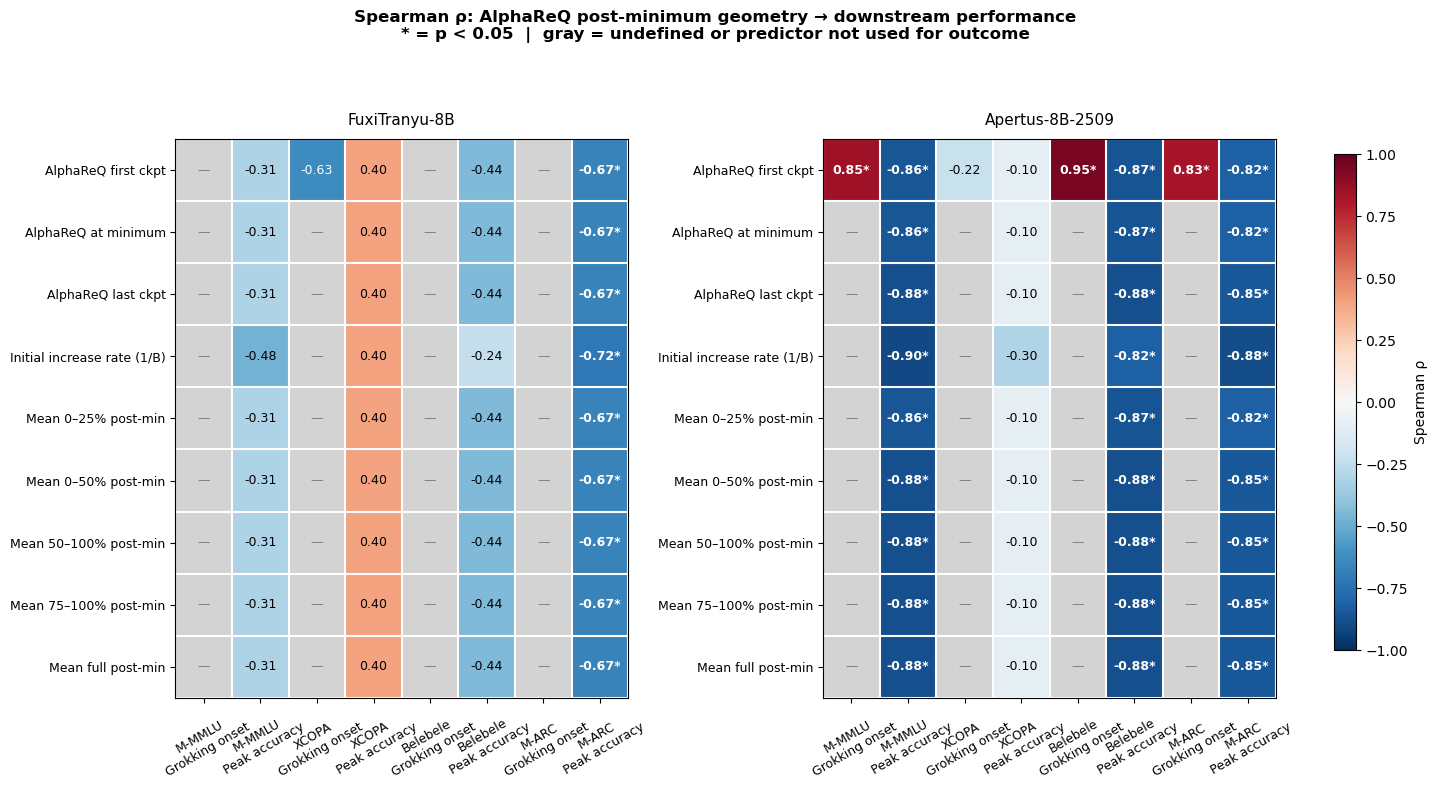

Saved: plots/alpha_correlation_heatmap.png


In [11]:
show_alpha_correlation_heatmap(MODELS, data)

### Selected Scatter Plot

**AlphaReQ at first checkpoint** is highlighted as the single most interpretable predictor: it requires only one forward pass at the very first checkpoint — no trough detection, no trajectory averaging — and is the only predictor used for grokking onset. The figure shows one row per task (m-MMLU, XCOPA, Belebele, M-ARC) against both outcomes, with per-model regression lines and Spearman/Pearson statistics.

> **What to look for:** For Apertus, a consistent pattern is visible for m-MMLU, Belebele, and M-ARC — languages with lower AlphaReQ at the first checkpoint (less self-regularization) correlate with earlier grokking onset and higher peak accuracy. XCOPA is the exception: all 5 languages score between 0.702 and 0.784, so outcomes are too tightly clustered for representational richness to differentiate them. For Fuxi, m-MMLU and Belebele stay at random chance throughout training, leaving no signal. Only M-ARC shows a meaningful correlation (Pearson r = -0.773, p = 0.014). For XCOPA there is no predictor that correlates significantly with either outcome.

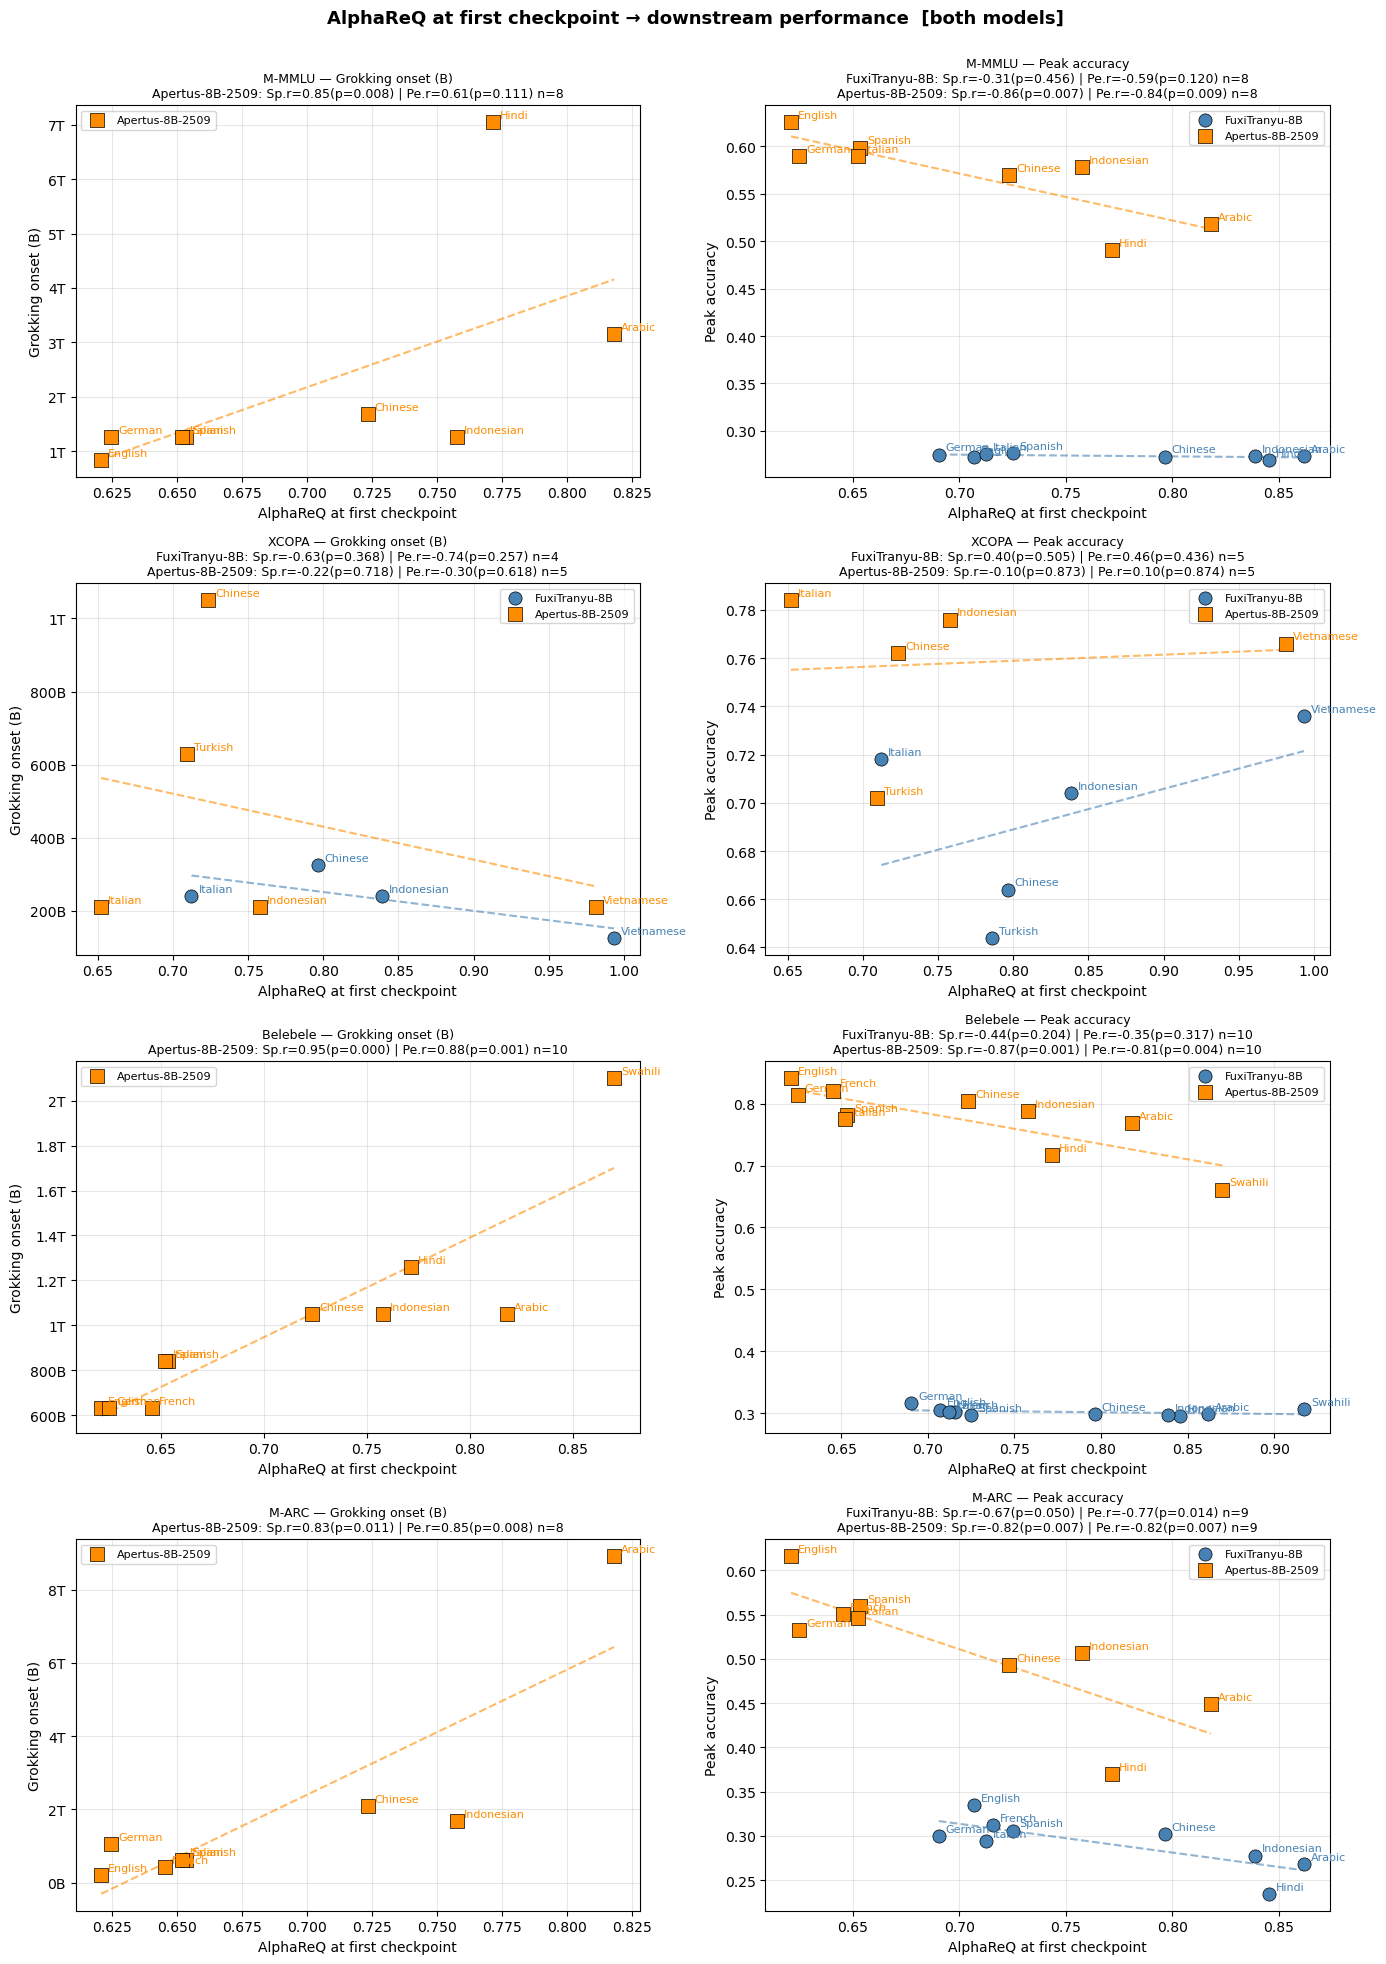

Saved: plots/scatter_alpha_first.png


In [12]:
show_predictor_scatter(MODELS, data, "alpha_first", "AlphaReQ at first checkpoint",
                       geometry_key="df_alpha_phases")

## AlphaReQ Predictor Analysis Findings

### FuxiTranyu-8B

**m-MMLU** — All 8 languages stay near random chance throughout training. No grokking detected, no significant predictor for peak accuracy.

**XCOPA** — 4 of 5 languages grokked (Turkish did not). Grokking onset (alpha_first, n=4): Sp r = −0.632, p = 0.368 — not significant; with n=4 the minimum exact two-tailed Spearman p-value is ≈ 0.083, so significance is structurally impossible. Peak accuracy: no predictor significant (all Sp p > 0.50).

**Belebele** — All 10 languages stay near random chance. No grokking detected, no significant predictor for peak accuracy.

**M-ARC** — No grokking detected. **Peak accuracy: all 9 predictors significant (all Sp p ≤ 0.050).** AlphaReQ at first ckpt: Sp r = −0.667, p = 0.050; strongest predictor: initial AlphaReQ increase rate Sp r = −0.717, p = 0.030 (Pe r = −0.747, p = 0.021). Direction: lower AlphaReQ at first checkpoint is associated with higher M-ARC accuracy, and a slower initial increase rate (more gradual rise in self-regularization) is also associated with higher M-ARC accuracy.

---

### Apertus-8B-2509

**m-MMLU** — All 8 languages grokked (840B–7 047B). Grokking onset (alpha_first): **Sp r = +0.850, p = 0.008** — lower AlphaReQ → earlier grokking. Peak accuracy: **all 9 predictors significant** (Sp r = −0.857 to −0.905, all p ≤ 0.007).

**XCOPA** — All 5 languages grokked. Grokking onset (alpha_first): Sp r = −0.224, p = 0.718 — not significant. Peak accuracy: **no predictor significant** (all Sp p > 0.62). XCOPA outcomes too tightly clustered (0.702–0.784) for AlphaReQ to differentiate languages.

**Belebele** — All 10 languages grokked (630B–2 100B). **Strongest AlphaReQ–performance relationship in the analysis.** Grokking onset (alpha_first): **Sp r = +0.947, p < 0.001**. Peak accuracy: **all 9 predictors significant** (Sp r = −0.818 to −0.879, all p < 0.005).

**M-ARC** — 8 of 9 languages grokked (Hindi did not). Grokking onset (alpha_first): **Sp r = +0.826, p = 0.011**. Peak accuracy: **all 9 predictors significant** (Sp r = −0.817 to −0.883, all p ≤ 0.007).

---

### Cross-model summary

**M-ARC is the only benchmark where AlphaReQ predicts peak accuracy in both models**, with consistent negative direction (lower AlphaReQ → higher accuracy and slower initial increase rate → higher accuracy).

All other cross-model comparisons fail: Fuxi never learns m-MMLU or Belebele during pre-training (accuracy stays at random chance, no variance to correlate), and XCOPA has no significant AlphaReQ signal in either model. The richness-predictor findings for Apertus (m-MMLU, Belebele, M-ARC) have no Fuxi counterpart — except M-ARC.

---

### 💡Key findings

- **Both models — M-ARC:** lower AlphaReQ at the first checkpoint predicts higher peak accuracy, replicating across both models with the same direction. This mirrors the cross-model M-ARC finding from the RankMe analysis.
- **Apertus — m-MMLU, Belebele, M-ARC:** all 9 AlphaReQ predictors are significant for peak accuracy; grokking onset strongly predicted by alpha_first (Sp r = +0.850, +0.947 and +0.826 respectively) — lower AlphaReQ → earlier grokking.
- **Both models — XCOPA:** no AlphaReQ predictor reaches significance for any outcome.
- **Fuxi — m-MMLU and Belebele:** no signal; accuracy stays at random chance throughout training, leaving no cross-language variance.

## Per-Checkpoint Correlation: Does geometry track the language performance hierarchy over training?

The previous predictor analysis tested whether a single AlphaReQ metric (computed from the full trajectory) predicts a language's final downstream outcome. Here we ask a complementary question: **at each training checkpoint, does the cross-language ranking of AlphaReQ match the cross-language ranking of accuracy at that same checkpoint?**

At any given checkpoint, we have two values per language — AlphaReQ and accuracy on a given task — and we compute **one Spearman correlation** across all languages. Repeating this at every checkpoint produces a curve that answers: **as training progresses, does the model's self-regularization geometry become a better or worse predictor of which languages it handles best?**

- A **positive ρ** means languages with higher AlphaReQ also have higher accuracy at that moment.
- A **near-zero ρ** means the two rankings are unrelated — the geometry has no predictive power at that checkpoint.
- **Filled markers** = p < 0.05 (statistically significant); **open markers** = p ≥ 0.05.

In [13]:
compute_and_show_checkpoint_correlations(MODELS, data, metric="alpha_req")


── FuxiTranyu-8B ────────────────────────────────────────
  m_mmlu: 2/57 checkpoints with p<0.05 | max ρ = 0.619 | min ρ = -0.762
  xcopa: 2/57 checkpoints with p<0.05 | max ρ = 0.900 | min ρ = -0.100
  belebele: 3/57 checkpoints with p<0.05 | max ρ = 0.782 | min ρ = -0.887
  m_arc: 35/57 checkpoints with p<0.05 | max ρ = 0.400 | min ρ = -0.900

── Apertus-8B-2509 ────────────────────────────────────────
  m_mmlu: 42/44 checkpoints with p<0.05 | max ρ = -0.143 | min ρ = -0.976
  xcopa: 0/44 checkpoints with p<0.05 | max ρ = 0.700 | min ρ = -0.200
  belebele: 42/44 checkpoints with p<0.05 | max ρ = -0.103 | min ρ = -0.988
  m_arc: 44/44 checkpoints with p<0.05 | max ρ = -0.767 | min ρ = -0.933


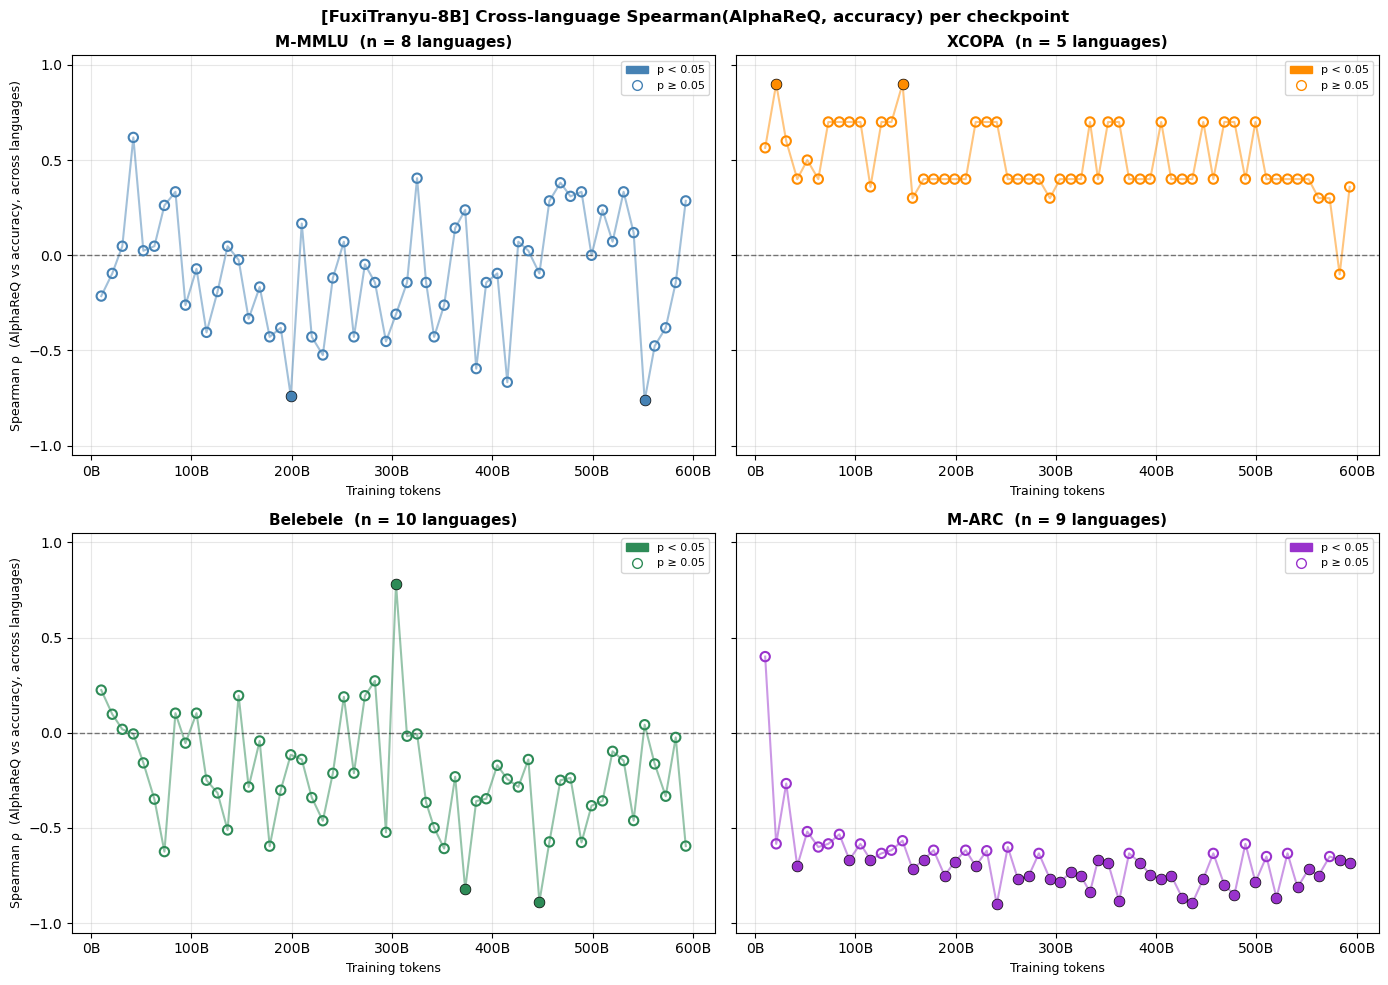

Saved: plots/alpha_req_checkpoint_correlations_fuxi.png


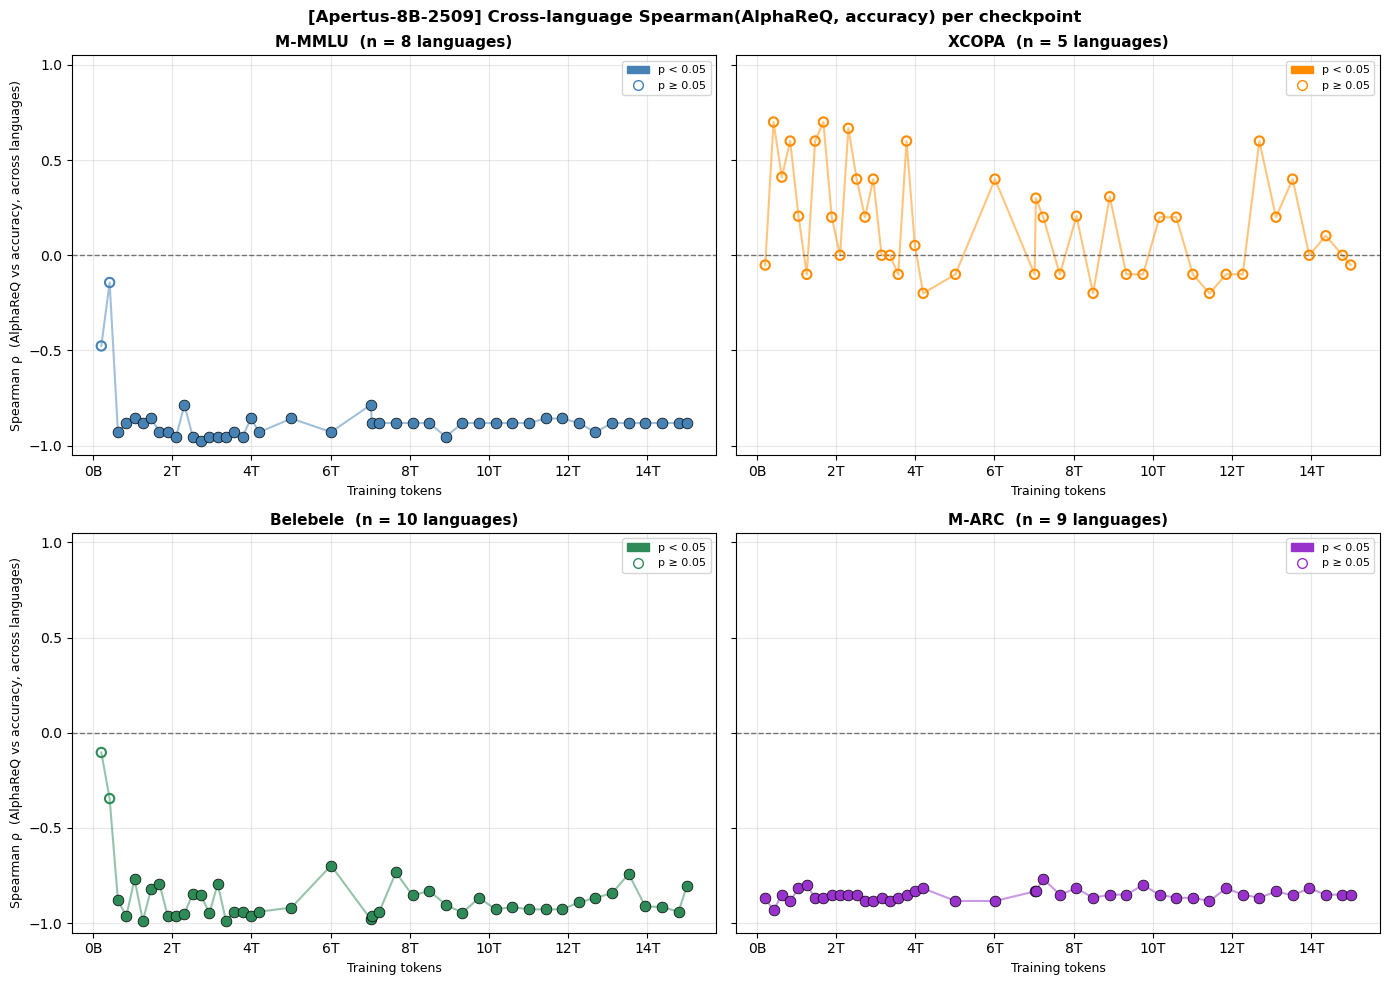

Saved: plots/alpha_req_checkpoint_correlations_apertus.png


In [14]:
show_checkpoint_correlations(MODELS, data, metric="alpha_req")

## Per-Checkpoint Correlation Findings

### FuxiTranyu-8B

**m-MMLU (8 languages): 2/57 checkpoints significant, max ρ = 0.619, min ρ = −0.762**

Near-zero and mixed-sign correlation throughout training, as expected. All 8 languages stay at random chance (~25%), leaving essentially no accuracy variance. The 2 significant checkpoints are noise.

**XCOPA (5 languages): 2/57 checkpoints significant, max ρ = +0.900, min ρ = −0.100**

Only 2/57 checkpoints significant. This is not an interpretable per-checkpoint signal for XCOPA in FuxiTranyu-8B, but the geometry ranking influences the accuracy ranking in the opposite direction to the M-ARC signal (the only other benchmark with a clear per-checkpoint direction), consistent with the anomaly seen in the RankMe analysis.

**Belebele (10 languages): 3/57 checkpoints significant, max ρ = 0.782, min ρ = −0.887**

Sparse and mixed-sign. All 10 languages stay near random chance throughout training (peak accuracy 0.296–0.317), leaving no meaningful cross-language accuracy variance. The 3 significant checkpoints are isolated and not a sustained pattern.

**M-ARC (9 languages): 35/57 checkpoints significant, max ρ = +0.400, min ρ = −0.900**

The strongest per-checkpoint AlphaReQ result for FuxiTranyu-8B: 35/57 significant checkpoints (61%), and all significant correlations are negative — lower AlphaReQ languages achieve higher M-ARC accuracy.

---

### Apertus-8B-2509

**m-MMLU (8 languages): 42/44 checkpoints significant, max ρ = −0.143, min ρ = −0.976**

Throughout 95% of training, the cross-language AlphaReQ ranking is significantly correlated with the m-MMLU accuracy ranking at that same checkpoint — and **every significant correlation is negative**: lower AlphaReQ → higher accuracy. Even the weakest significant correlation is negative (max ρ = −0.143). This is the AlphaReQ mirror of the RankMe result (40/44 significant, all positive ρ): both metrics encode the same language hierarchy, in opposite directions.

**XCOPA (5 languages): 0/44 checkpoints significant, max ρ = +0.700, min ρ = −0.200**

No significant correlation at any checkpoint. With n=5 languages the critical Spearman ρ for p < 0.05 two-tailed is ≈ 0.900, so the observed maximum ρ = +0.700 cannot reach significance regardless of direction. Consistent with the static predictor analysis where no AlphaReQ predictor reached significance for XCOPA.

**Belebele (10 languages): 42/44 checkpoints significant, max ρ = −0.103, min ρ = −0.988**

95% of checkpoints are significant, and **all correlations are negative** — including the weakest (max ρ = −0.103). The minimum ρ = −0.988 is the strongest per-checkpoint correlation in this notebook. The 2 non-significant checkpoints are the very earliest, before any language has crossed the grokking threshold (all grokk between 630B and 2 100B).

**M-ARC (9 languages): 44/44 checkpoints significant, max ρ = −0.767, min ρ = −0.933**

Every single checkpoint is significant (100%), and **all correlations are strongly negative** — even the weakest is ρ = −0.767. At every training checkpoint, lower AlphaReQ languages have higher M-ARC accuracy. This is the most consistent result in the notebook and replicates the cross-model M-ARC finding from the predictor analysis.

---

### Cross-model summary

**M-ARC is the only benchmark with significant per-checkpoint AlphaReQ correlations in both models** — 35/57 for FuxiTranyu-8B and 44/44 for Apertus-8B-2509 — and the dominant direction is negative in both (lower AlphaReQ → higher M-ARC accuracy). This replicates the per-checkpoint RankMe pattern for M-ARC, where the correlation was positive (higher RankMe → higher M-ARC accuracy): both metrics point to the same underlying language hierarchy, in opposite directions.

All significant Apertus correlations are negative, directly mirroring the RankMe analysis where all significant Apertus correlations were positive. Lower AlphaReQ ↔ higher RankMe ↔ better downstream outcomes.

---

### 💡Key findings

- **Both models — M-ARC:** AlphaReQ is negatively correlated with M-ARC accuracy at most/all checkpoints (35/57 for Fuxi, 44/44 for Apertus), with lower AlphaReQ tracking higher accuracy throughout training.
- **Apertus — m-MMLU and Belebele:** all significant per-checkpoint AlphaReQ correlations are negative (95% of checkpoints).
- **Both models — XCOPA:** no sustained per-checkpoint signal. For Apertus, 0/44 significant — the observed max ρ = +0.700 never reaches the ~0.900 threshold required for n=5. For Fuxi, 2/57 isolated significant checkpoints but no sustained pattern.
- **Fuxi — m-MMLU and Belebele:** no per-checkpoint signal; accuracy stays at random chance throughout training, leaving no cross-language variance to detect.